In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

print("Capstone environment ready")

Capstone environment ready


In [2]:
months = np.arange(0, 24)

well_A = np.array([
    1800,1700,1600,1500,1420,1350,
    1280,1220,1160,1100,1050,1000,
    960,920,880,850,820,790,
    760,740,720,700,680,660
])

well_B = np.array([
    1600,1550,1480,1400,1330,1260,
    1190,1130,1080,1030,990,950,
    920,890,860,830,800,770,
    750,730,710,690,670,650
])

df = pd.DataFrame({
    "Month": months,
    "Well_A_bopd": well_A,
    "Well_B_bopd": well_B
})

df.head()

,Month,Well_A_bopd,Well_B_bopd
0,0,1800,1600
1,1,1700,1550
2,2,1600,1480
3,3,1500,1400
4,4,1420,1330


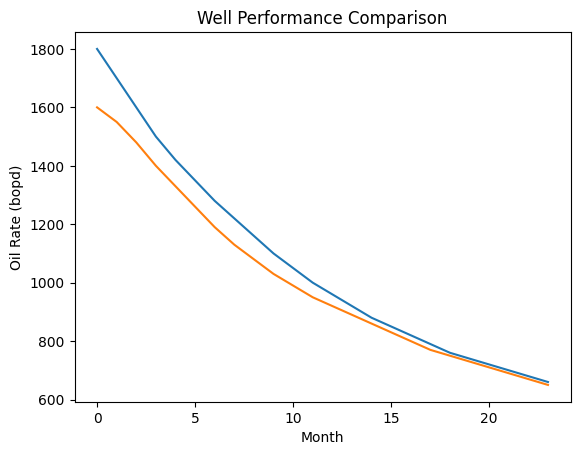

In [3]:
plt.figure()
plt.plot(df["Month"], df["Well_A_bopd"])
plt.plot(df["Month"], df["Well_B_bopd"])
plt.xlabel("Month")
plt.ylabel("Oil Rate (bopd)")
plt.title("Well Performance Comparison")
plt.show()

In [4]:
df["Well_A_Cum"] = (df["Well_A_bopd"] * 30).cumsum()
df["Well_B_Cum"] = (df["Well_B_bopd"] * 30).cumsum()

df.tail()

,Month,Well_A_bopd,Well_B_bopd,Well_A_Cum,Well_B_Cum
19,19,740,730,687000,646200
20,20,720,710,708600,667500
21,21,700,690,729600,688200
22,22,680,670,750000,708300
23,23,660,650,769800,727800


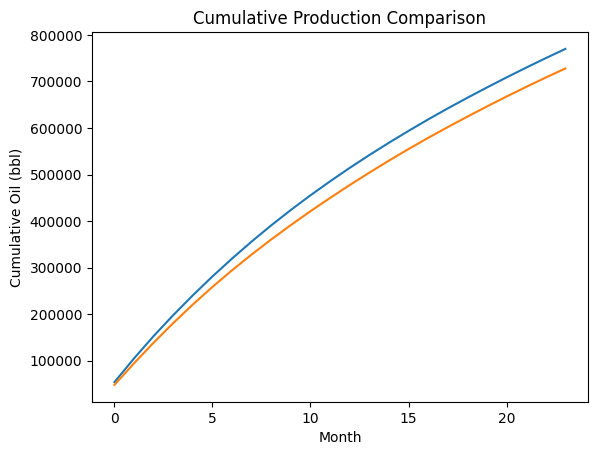

In [5]:
plt.figure()
plt.plot(df["Month"], df["Well_A_Cum"])
plt.plot(df["Month"], df["Well_B_Cum"])
plt.xlabel("Month")
plt.ylabel("Cumulative Oil (bbl)")
plt.title("Cumulative Production Comparison")
plt.show()

In [6]:
def hyperbolic_decline(t, qi, D, b):
    return qi / ((1 + b * D * t) ** (1 / b))

In [7]:
params_A, _ = curve_fit(hyperbolic_decline, df["Month"], df["Well_A_bopd"], maxfev=5000)
qi_A, D_A, b_A = params_A

In [8]:
params_B, _ = curve_fit(hyperbolic_decline, df["Month"], df["Well_B_bopd"], maxfev=5000)
qi_B, D_B, b_B = params_B

In [9]:
forecast_months = np.arange(0, 120)

forecast_A = hyperbolic_decline(forecast_months, qi_A, D_A, b_A)
forecast_B = hyperbolic_decline(forecast_months, qi_B, D_B, b_B)

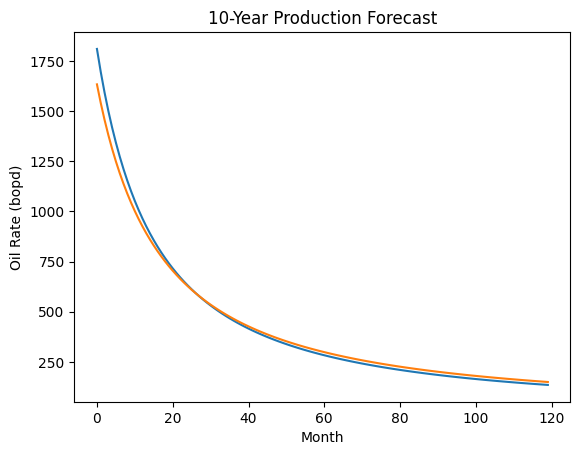

In [10]:
plt.figure()
plt.plot(forecast_months, forecast_A)
plt.plot(forecast_months, forecast_B)
plt.xlabel("Month")
plt.ylabel("Oil Rate (bopd)")
plt.title("10-Year Production Forecast")
plt.show()